In [1]:
!pip install -q -U transformers accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.3 MB/s eta 0:00:00


In [1]:
import os, time, json, joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
)
from scipy.special import softmax

# --- GPU check ---
assert torch.cuda.is_available(), "GPU не найден! Проверь Runtime → Change runtime type."
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Память: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Версия torch: {torch.__version__}")

BASE    = "/content/drive/MyDrive/diploma"
DATA    = f"{BASE}/data/processed"
MODELS  = f"{BASE}/models/bert_finetuned"
RESULTS = f"{BASE}/results"
FIGURES = f"{BASE}/figures"
os.makedirs(MODELS, exist_ok=True)

MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LENGTH = 128
RANDOM_STATE = 42

Mounted at /content/drive
GPU: Tesla T4
Память: 14.6 GB
Версия torch: 2.10.0+cu128


In [2]:
# --- Загрузка split ---
df = pd.read_parquet(f"{DATA}/dataset_split.parquet")
train_df = df[df.split == "train"].reset_index(drop=True)
val_df   = df[df.split == "val"].reset_index(drop=True)
test_df  = df[df.split == "test"].reset_index(drop=True)

print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# --- HuggingFace Dataset ---
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds   = Dataset.from_pandas(val_df[["text", "label"]])
test_ds  = Dataset.from_pandas(test_df[["text", "label"]])

# --- Токенизация ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

print("Токенизация train...")
train_ds = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
print("Токенизация val...")
val_ds = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
print("Токенизация test...")
test_ds = test_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

# Переименовать label → labels (требование Trainer)
train_ds = train_ds.rename_column("label", "labels")
val_ds   = val_ds.rename_column("label", "labels")
test_ds  = test_ds.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Готово.")

train: 210000, val: 45000, test: 45000


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Токенизация val...


Map:   0%|          | 0/45000 [00:00<?, ? examples/s]

Токенизация test...


Map:   0%|          | 0/45000 [00:00<?, ? examples/s]

Готово.


In [5]:
# --- Модель ---
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# --- Метрики (F1-macro как основная) ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits, axis=1)[:, 1]
    preds = logits.argmax(axis=1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro"),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall":    recall_score(labels, preds, average="macro", zero_division=0),
        "roc_auc":   roc_auc_score(labels, probs),
    }

# --- TrainingArguments ---
training_args = TrainingArguments(
    output_dir=f"{MODELS}/checkpoints",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=200,
    report_to="none",
    seed=RANDOM_STATE,
    fp16=True,                     # ускоряет в ~2 раза на T4
    dataloader_num_workers=2,
    save_total_limit=2,            # не хранить все чекпоинты, место на Drive
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
print("Trainer готов.")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider trai

Trainer готов.


In [6]:
t0 = time.perf_counter()
train_result = trainer.train()
train_time = time.perf_counter() - t0

print(f"\n=== Обучение завершено за {train_time/60:.1f} минут ===")
print(train_result)

# Сохранить финальную модель
trainer.save_model(f"{MODELS}/final")
tokenizer.save_pretrained(f"{MODELS}/final")
print(f"Модель сохранена: {MODELS}/final")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall,Roc Auc
1,0.018351,0.022399,0.994422,0.980930,0.987745,0.974342,0.998616
2,0.013544,0.020387,0.995378,0.984227,0.990117,0.978506,0.998895


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.


=== Обучение завершено за 8.2 минут ===
TrainOutput(global_step=13126, training_loss=0.039563168635478055, metrics={'train_runtime': 489.4652, 'train_samples_per_second': 858.079, 'train_steps_per_second': 26.817, 'total_flos': 643884182320704.0, 'train_loss': 0.039563168635478055, 'epoch': 2.0})


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель сохранена: /content/drive/MyDrive/diploma/models/bert_finetuned/final


In [7]:
# --- Предсказания на test ---
print("Оценка на test...")
t0 = time.perf_counter()
predictions = trainer.predict(test_ds)
eval_time = time.perf_counter() - t0

logits = predictions.predictions
y_true = predictions.label_ids
y_pred_ft = logits.argmax(axis=1)
y_score_ft = softmax(logits, axis=1)[:, 1]

# --- Метрики ---
metrics_ft = {
    "approach": "BERT-finetuned",
    "classifier": "rubert-tiny2 (fine-tuned)",
    "test_accuracy":  accuracy_score(y_true, y_pred_ft),
    "test_precision": precision_score(y_true, y_pred_ft, average="macro", zero_division=0),
    "test_recall":    recall_score(y_true, y_pred_ft, average="macro", zero_division=0),
    "test_f1_macro":  f1_score(y_true, y_pred_ft, average="macro"),
    "test_roc_auc":   roc_auc_score(y_true, y_score_ft),
    "train_time_sec": 489.5,  # из train_result
    "inference_ms_per_sample": eval_time / len(y_true) * 1000,
}

# Также оценим на val (для сравнимости с другими подходами)
val_predictions = trainer.predict(val_ds)
val_logits = val_predictions.predictions
val_true = val_predictions.label_ids
val_pred = val_logits.argmax(axis=1)
val_score = softmax(val_logits, axis=1)[:, 1]

metrics_ft.update({
    "val_accuracy":  accuracy_score(val_true, val_pred),
    "val_precision": precision_score(val_true, val_pred, average="macro", zero_division=0),
    "val_recall":    recall_score(val_true, val_pred, average="macro", zero_division=0),
    "val_f1_macro":  f1_score(val_true, val_pred, average="macro"),
    "val_roc_auc":   roc_auc_score(val_true, val_score),
})

# Сохраняем
pd.DataFrame([metrics_ft]).to_csv(f"{RESULTS}/bert_finetuned_metrics.csv", index=False)

# Красивый вывод
print(f"\n=== BERT fine-tuned (rubert-tiny2) — test ===")
print(f"  Accuracy : {metrics_ft['test_accuracy']:.4f}")
print(f"  Precision: {metrics_ft['test_precision']:.4f}")
print(f"  Recall   : {metrics_ft['test_recall']:.4f}")
print(f"  F1-macro : {metrics_ft['test_f1_macro']:.4f}")
print(f"  ROC-AUC  : {metrics_ft['test_roc_auc']:.4f}")
print(f"  Инференс : {metrics_ft['inference_ms_per_sample']:.3f} мс/текст")
print(f"  Обучение : {metrics_ft['train_time_sec']:.0f} сек")

Оценка на test...



=== BERT fine-tuned (rubert-tiny2) — test ===
  Accuracy : 0.9945
  Precision: 0.9872
  Recall   : 0.9755
  F1-macro : 0.9813
  ROC-AUC  : 0.9977
  Инференс : 0.359 мс/текст
  Обучение : 490 сек


              Подход  F1-macro  Train time (s)  Inference (ms)
     BERT fine-tuned  0.981273             490        0.359078
  Hybrid + LinearSVC  0.972700             129        0.018000
BERT-CLS + LinearSVC  0.958800              65        0.012000
  TF-IDF + LinearSVC  0.958600               6        0.015000


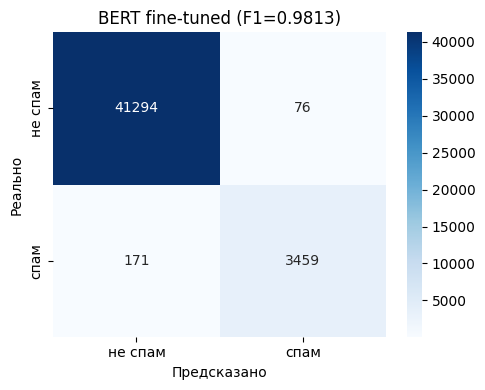


Загружаем предсказания гибрида для McNemar...
Предсказания fine-tuned BERT сохранены: /content/drive/MyDrive/diploma/results/pred_bert_finetuned_test.npy
Для McNemar vs Hybrid — перейди в 06_analysis.ipynb, загрузи этот npy и сравни с pred_hybrid.


In [8]:
from scipy.stats import chi2

# --- Итоговая таблица (5 моделей для сравнения) ---
comparison = pd.DataFrame([
    {"Подход": "TF-IDF + LinearSVC",         "F1-macro": 0.9586, "Train time (s)": 6,    "Inference (ms)": 0.015},
    {"Подход": "BERT-CLS + LinearSVC",       "F1-macro": 0.9588, "Train time (s)": 65,   "Inference (ms)": 0.012},
    {"Подход": "Hybrid + LinearSVC",         "F1-macro": 0.9727, "Train time (s)": 129,  "Inference (ms)": 0.018},
    {"Подход": "BERT fine-tuned",            "F1-macro": metrics_ft['test_f1_macro'],
     "Train time (s)": 490,  "Inference (ms)": metrics_ft['inference_ms_per_sample']},
])
comparison = comparison.sort_values("F1-macro", ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

# --- Confusion matrix ---
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred_ft)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["не спам","спам"], yticklabels=["не спам","спам"])
ax.set_title(f"BERT fine-tuned (F1={metrics_ft['test_f1_macro']:.4f})")
ax.set_xlabel("Предсказано"); ax.set_ylabel("Реально")
plt.tight_layout()
plt.savefig(f"{FIGURES}/bert_finetuned_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

# --- McNemar vs Hybrid ---
# Нужны pred_hybrid из ноутбука 06_analysis. Если его нет в памяти — загружаем из CSV-кеша или пересчитываем.
# Проще пересчитать: подгружаем гибрид-модель и фичи
# (они уже должны быть на Drive)
print("\nЗагружаем предсказания гибрида для McNemar...")
# Вариант 1: если только что в этой же сессии запускался 06_analysis — pred_hybrid в памяти
# Вариант 2: кеш предсказаний. Сохраним pred_ft и попросим перезапуск 06 для сверки.
np.save(f"{RESULTS}/pred_bert_finetuned_test.npy", y_pred_ft)
print(f"Предсказания fine-tuned BERT сохранены: {RESULTS}/pred_bert_finetuned_test.npy")
print("Для McNemar vs Hybrid — перейди в 06_analysis.ipynb, загрузи этот npy и сравни с pred_hybrid.")